---
authors:
  - name: Patrick Erdelt
    email: perdelt@bht-berlin.de
  - name: Felix Bießmann
    email: felix.biessmann@bht-berlin.de
  - name: Leonhard Liu
    email: leonhard.liu@bht-berlin.de
---

# Session 7: Content-Based Methods

> *"The set of documents in a collection then may be viewed as a set of vectors in a vector space, in which there is one axis for each term."*
> — Manning, Raghavan & Schütze, *Introduction to Information Retrieval* (Cambridge UP, 2008), Ch. 6

**Core idea:** describe every item *and* every user as a vector of features, then let **angle and distance** decide what is similar.

In [1]:
# Setup — run this first
# install deps only if missing (already present via `uv sync`; pip-installs on Colab)
import importlib.util, subprocess, sys
_need = {'pandas': 'pandas', 'numpy': 'numpy', 'matplotlib': 'matplotlib',
         'seaborn': 'seaborn', 'scikit-learn': 'sklearn'}
_missing = [pip for pip, mod in _need.items() if importlib.util.find_spec(mod) is None]
if _missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *_missing], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
import urllib.request, zipfile, os

plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 13, 'axes.titlesize': 16})

# MovieLens (small) — downloaded at runtime, not committed
if not os.path.exists('ml-latest-small'):
    urllib.request.urlretrieve(
        'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'ml.zip')
    with zipfile.ZipFile('ml.zip', 'r') as z:
        z.extractall('.')

movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')
print(f'{len(movies)} movies, {len(ratings):,} ratings loaded')

9742 movies, 100,836 ratings loaded


---
## What is a vector?

A vector is just a list of numbers that describes something.  
If we have two numbers, we can draw it as a point in 2D.

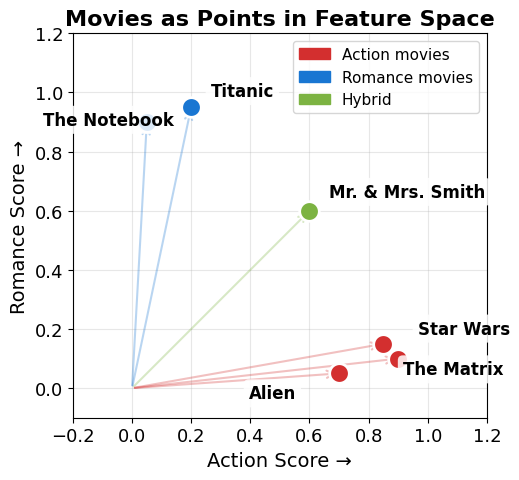

Similar movies are CLOSE in this space. That's the whole idea.


In [2]:
# 2D example: movies described by two features. Labels are hand-offset so close pairs
# (Titanic ↔ The Notebook, Star Wars ↔ The Matrix) don't overlap.
fig, ax = plt.subplots(figsize=(7.5, 5.0))

movie_points = {
    'Star Wars':        (0.90, 0.10),
    'The Matrix':       (0.85, 0.15),
    'Alien':            (0.70, 0.05),
    'Titanic':          (0.20, 0.95),
    'The Notebook':     (0.05, 0.90),
    'Mr. & Mrs. Smith': (0.60, 0.60),
}

# Per-movie label offsets (dx_pts, dy_pts) — chosen so labels don't collide with each other
# or with the dot. Star Wars / Matrix / Alien sit in a tight cluster, so we fan them out
# top/right/bottom; Titanic vs Notebook split left/right.
label_offsets = {
    'Star Wars':        (14,  18),    # up-right of the dot
    'The Matrix':       (14, -22),    # down-right of the dot (clears Star Wars above)
    'Alien':            (-65,-18),    # down-left of the dot
    'Titanic':          (14,   8),    # right of the dot
    'The Notebook':     (-75, -2),    # left of the dot (clears Titanic on the right)
    'Mr. & Mrs. Smith': (14,  10),
}

colors = {'Star Wars': '#d32f2f', 'The Matrix': '#d32f2f', 'Alien': '#d32f2f',
          'Titanic':   '#1976d2', 'The Notebook': '#1976d2', 'Mr. & Mrs. Smith': '#7cb342'}

# Arrows from origin first (so dots sit on top of them).
for name, (x, y) in movie_points.items():
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors[name], alpha=0.30, lw=1.5))

# Then dots + labels with translucent boxes.
for name, (x, y) in movie_points.items():
    ax.scatter(x, y, s=200, c=colors[name], zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(name, (x, y), textcoords='offset points', xytext=label_offsets[name],
                fontsize=12, fontweight='bold', zorder=6,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none'))

ax.set_xlim(-0.20, 1.20)
ax.set_ylim(-0.10, 1.20)
ax.set_xlabel('Action Score →', fontsize=14)
ax.set_ylabel('Romance Score →', fontsize=14)
ax.set_title('Movies as Points in Feature Space', fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax.legend(handles=[mpatches.Patch(color='#d32f2f', label='Action movies'),
                   mpatches.Patch(color='#1976d2', label='Romance movies'),
                   mpatches.Patch(color='#7cb342', label='Hybrid')],
          fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()
print('Similar movies are CLOSE in this space. That\'s the whole idea.')


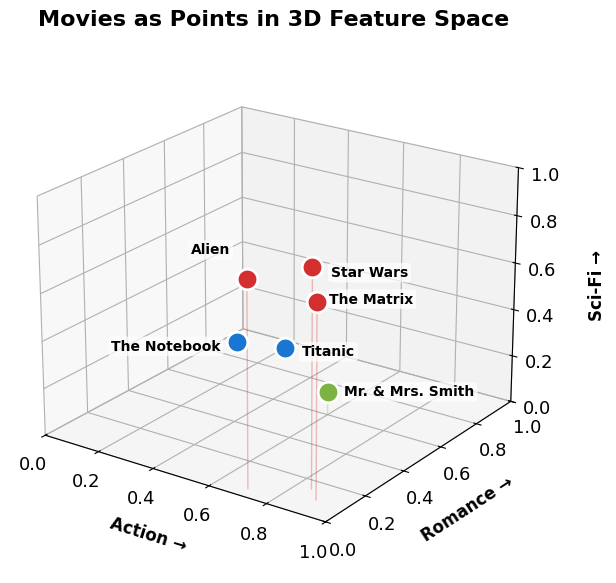

Action movies (red) cluster at high Action + Sci-Fi; romances (blue) sit on the floor (Sci-Fi = 0).


In [3]:
# Same six movies, now with a 3rd axis (Sci-Fi). Action movies separate by how much sci-fi they add.
# Labels use proj_transform + 2-D pixel offsets so close pairs (Titanic/Notebook, Star Wars/Matrix)
# can be placed precisely in screen space — 3-D label offsets are unreliable.
from mpl_toolkits.mplot3d import proj3d

movies_3d = {
    'Star Wars':        (0.90, 0.10, 0.80),
    'The Matrix':       (0.85, 0.15, 0.90),
    'Alien':            (0.70, 0.05, 0.85),
    'Titanic':          (0.20, 0.95, 0.00),
    'The Notebook':     (0.05, 0.90, 0.00),
    'Mr. & Mrs. Smith': (0.60, 0.60, 0.10),
}
colors3d = {'Star Wars': '#d32f2f', 'The Matrix': '#d32f2f', 'Alien': '#d32f2f',
            'Titanic': '#1976d2', 'The Notebook': '#1976d2', 'Mr. & Mrs. Smith': '#7cb342'}

# Per-label pixel offsets (dx, dy) from the projected dot position, plus alignment.
label_style = {
    #             (dx,  dy,  ha,     va)
    'Star Wars':        (10,  16, 'left',  'bottom'),
    'The Matrix':       (12, -18, 'left',  'top'),
    'Alien':            (-12, 16, 'right', 'bottom'),
    'Titanic':          (12,  -3, 'left',  'center'),
    'The Notebook':     (-12, -3, 'right', 'center'),
    'Mr. & Mrs. Smith': (12,   0, 'left',  'center'),
}

fig = plt.figure(figsize=(8.5, 6.0))
ax = fig.add_subplot(111, projection='3d')

for name, (x, y, z) in movies_3d.items():
    ax.scatter(x, y, z, s=220, c=colors3d[name], edgecolors='white', linewidth=2)
    ax.plot([x, x], [y, y], [0, z], color=colors3d[name], alpha=0.30, lw=1)

ax.view_init(elev=22, azim=-55)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)

ax.set_xlabel('Action ' + chr(0x2192),  fontsize=12, labelpad=10, fontweight='bold')
ax.set_ylabel('Romance ' + chr(0x2192), fontsize=12, labelpad=10, fontweight='bold')
ax.set_zlabel('')
ax.set_title('Movies as Points in 3D Feature Space', fontweight='bold', pad=14)

# Draw once so the projection matrix is up to date, then add screen-space labels.
fig.canvas.draw()
for name, (x, y, z) in movies_3d.items():
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    dx, dy, ha, va = label_style[name]
    ax.annotate(name, xy=(x2, y2), xycoords='data',
                xytext=(dx, dy), textcoords='offset points',
                fontsize=10, fontweight='bold', ha=ha, va=va,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='none', alpha=0.7))

fig.text(0.79, 0.52, 'Sci-Fi ' + chr(0x2192), fontsize=12, fontweight='bold', rotation=90,
         va='center', ha='left')
fig.subplots_adjust(left=0.02, right=0.82, top=0.92, bottom=0.04)
plt.show()
print('Action movies (red) cluster at high Action + Sci-Fi; romances (blue) sit on the floor (Sci-Fi = 0).')



## From 2 features to 3 … to hundreds

Two numbers → a point in 2D. Add a third feature (**Sci-Fi**) and the same movies spread out in 3D.

The math never cares how many axes there are — a movie with 20 genres is just a point in 20-dimensional space. We simply can't *draw* past three. 

---
## Building the Item-Feature Matrix

Each movie has genres. We turn them into a **binary vector** (one-hot encoding).

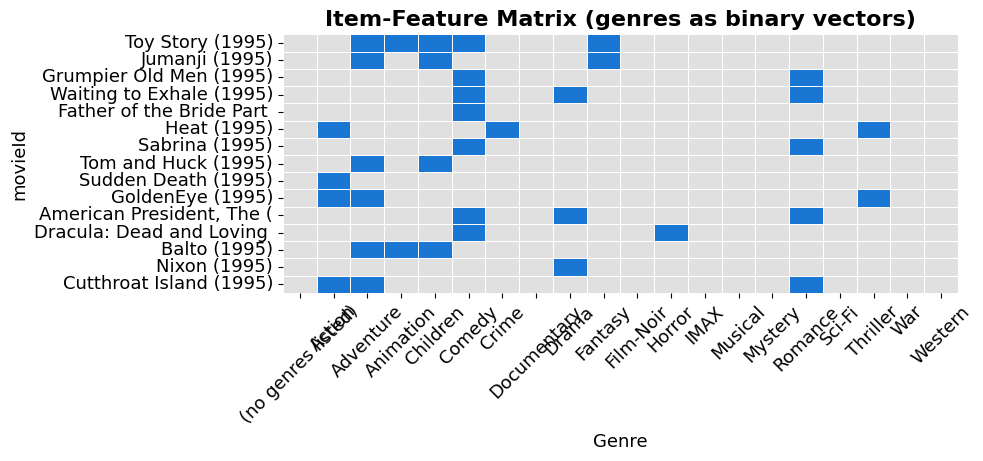

Each movie is a vector with 20 dimensions (one per genre).


In [4]:

# One-hot encode genres
genre_matrix = movies['genres'].str.get_dummies(sep='|')
genre_matrix.index = movies['movieId']

# Visualize a slice
sample_ids = movies.head(15)['movieId'].values
sample_titles = movies.head(15)['title'].str[:25].values
sample_genres = genre_matrix.loc[sample_ids]

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(sample_genres, cmap=['#e0e0e0', '#1976d2'], cbar=False,
            linewidths=0.5, linecolor='white', ax=ax,
            yticklabels=sample_titles)
ax.set_title('Item-Feature Matrix (genres as binary vectors)', fontweight='bold')
ax.set_xlabel('Genre')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Each movie is a vector with {genre_matrix.shape[1]} dimensions (one per genre).')

### Seeing all of them at once

We can't plot 20 genre-dimensions, so we **project** every movie down to 2D with PCA — neighbours in this picture really are similar in genre space.

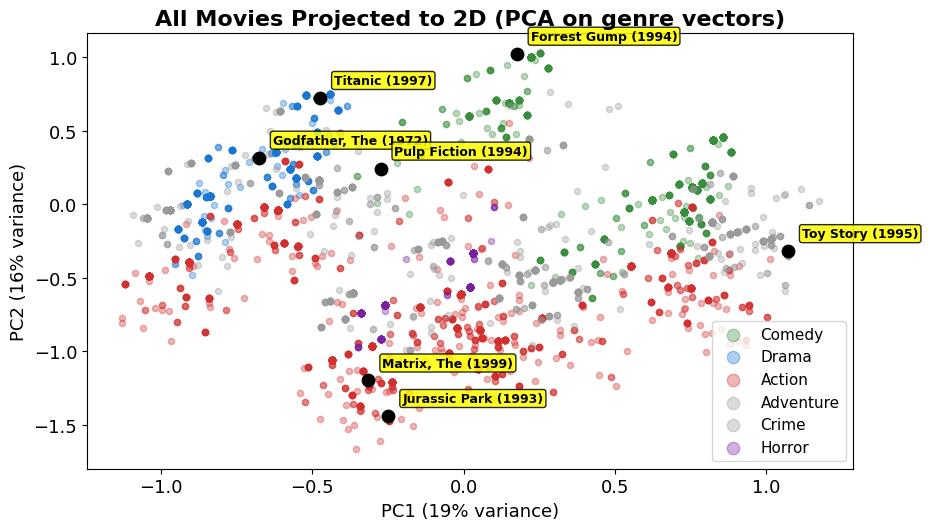

Similar genre profiles → close in space. But 2D is a rough approximation of 20 dimensions.


In [5]:

pca = PCA(n_components=2)
movies_2d = pca.fit_transform(genre_matrix)

movies['primary_genre'] = movies['genres'].str.split('|').str[0]
top_genres = movies['primary_genre'].value_counts().head(6).index

genre_colors = {'Drama':'#1976d2', 'Comedy':'#388e3c', 'Action':'#d32f2f',
                'Horror':'#7b1fa2', 'Thriller':'#f57c00', 'Romance':'#e91e63'}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for genre in top_genres:
    mask = movies['primary_genre'] == genre
    ax.scatter(movies_2d[mask, 0], movies_2d[mask, 1],
               label=genre, alpha=0.35, s=20,
               color=genre_colors.get(genre, '#999'))

# Label some well-known movies
for name in ['Toy Story', 'Matrix', 'Titanic', 'Godfather', 'Pulp Fiction', 'Jurassic Park', 'Forrest Gump']:
    match = movies[movies['title'].str.contains(name, case=False)]
    if len(match) > 0:
        i = match.index[0]
        ax.annotate(match['title'].values[0][:25], (movies_2d[i, 0], movies_2d[i, 1]),
                    textcoords='offset points', xytext=(10, 10),
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.85))
        ax.scatter(movies_2d[i, 0], movies_2d[i, 1], s=80, color='black', zorder=5)

ax.set_title('All Movies Projected to 2D (PCA on genre vectors)', fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
plt.tight_layout()
plt.show()
print('Similar genre profiles → close in space. But 2D is a rough approximation of 20 dimensions.')

## Beyond genres: richer movie vectors

We started with just **genre flags** (~20 dimensions). Real recommenders add **whatever signal helps**:

| Source            | Example features                                  |
|-------------------|---------------------------------------------------|
| **Cast & crew**   | director, lead actors, composer, cinematographer  |
| **Plot keywords** | "time travel", "heist", "based on true story"     |
| **Metadata**      | year, runtime, country, MPAA rating               |
| **User signals**  | tags, average rating, popularity                  |

Every new feature is **another dimension** of the same vector. Two movies sharing the same director or composer become close even if their genres differ — capturing the kind of "more of the same" that genres alone miss.

*(More dimensions = more nuance, but also the curse of dimensionality. Watch for that in a few slides.)*


## Users are vectors too

Describe each user with the **same feature axes** as the items. Then a recommender is just: "find items whose vector points the same way as this user's."

A user vector can come from a **questionnaire**, the **average of items they watched/clicked**, or **feature extraction** over their history.

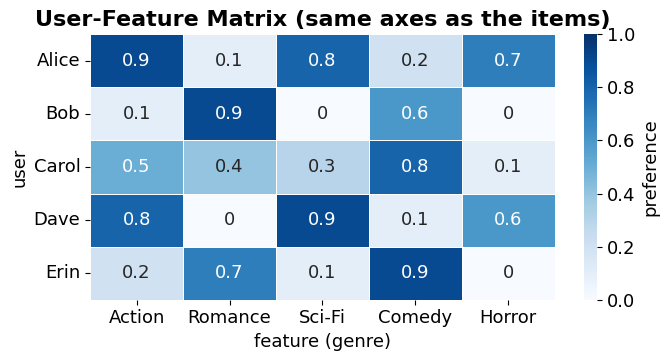

Alice and Dave both love Action + Sci-Fi -> their vectors point the same way -> similar taste.


In [6]:
# A made-up user-feature matrix: how strongly each user likes each genre (0-1),
# living in the SAME feature space as the items.
user_features = pd.DataFrame(
    {'Action':  [0.9, 0.1, 0.5, 0.8, 0.2],
     'Romance': [0.1, 0.9, 0.4, 0.0, 0.7],
     'Sci-Fi':  [0.8, 0.0, 0.3, 0.9, 0.1],
     'Comedy':  [0.2, 0.6, 0.8, 0.1, 0.9],
     'Horror':  [0.7, 0.0, 0.1, 0.6, 0.0]},
    index=['Alice', 'Bob', 'Carol', 'Dave', 'Erin'])

fig, ax = plt.subplots(figsize=(7.0, 3.8))
hm = sns.heatmap(user_features, annot=True, cmap='Blues', vmin=0, vmax=1,
            cbar_kws={'label': 'preference'}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('User-Feature Matrix (same axes as the items)', fontweight='bold')
plt.setp(hm.get_yticklabels(), rotation=0)
plt.setp(hm.get_xticklabels(), rotation=0)
ax.set_xlabel('feature (genre)')
ax.set_ylabel('user')
plt.tight_layout()
plt.show()
print('Alice and Dave both love Action + Sci-Fi -> their vectors point the same way -> similar taste.')

## Comparing Vectors: Dot Product

Multiply matching components, then sum — both as an algebraic recipe and a geometric identity:

$$\vec{a}\cdot\vec{b} \;=\; \sum_i a_i\,b_i \;=\; \lVert\vec{a}\rVert\,\lVert\vec{b}\rVert\,\cos(\theta)$$

**Worked example.** With $\vec{a} = (3,\,1,\,2)$ and $\vec{b} = (1,\,4,\,2)$:

$$\vec{a}\cdot\vec{b} \;=\; 3{\cdot}1 + 1{\cdot}4 + 2{\cdot}2 \;=\; \boxed{\,11\,}$$

And the **length** (Euclidean norm, used in every formula below) of a vector:

$$\lVert\vec{a}\rVert \;=\; \sqrt{\textstyle\sum_i a_i^{\,2}} \;=\; \sqrt{3^2 + 1^2 + 2^2} \;=\; \sqrt{14} \;\approx\; 3.74$$


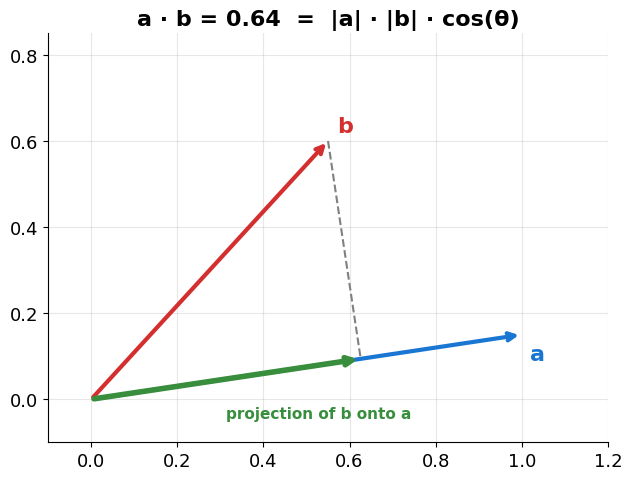

A longer b gives a bigger dot product at the same angle. Cosine divides by both lengths, so only the angle survives.


In [7]:
# Dot product as a projection: a . b = |a| * (length of b projected onto a)
fig, ax = plt.subplots(figsize=(7.5, 5.0))
a = np.array([1.0, 0.15])
b = np.array([0.55, 0.60])
a_hat = a / np.linalg.norm(a)
proj = np.dot(b, a_hat) * a_hat                 # vector projection of b onto a

ax.annotate('', xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#1976d2'))
ax.annotate('', xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#d32f2f'))
ax.annotate('', xy=proj, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=4, color='#388e3c'))
ax.plot([b[0], proj[0]], [b[1], proj[1]], ls='--', color='gray', lw=1.5)   # drop line
ax.text(a[0] + 0.02, a[1] - 0.06, 'a', color='#1976d2', fontsize=16, fontweight='bold')
ax.text(b[0] + 0.02, b[1] + 0.02, 'b', color='#d32f2f', fontsize=16, fontweight='bold')
ax.text(proj[0] * 0.5, proj[1] * 0.5 - 0.09, 'projection of b onto a',
        color='#388e3c', fontsize=11, fontweight='bold')

ax.set_title(f'a · b = {np.dot(a, b):.2f}  =  |a| · |b| · cos(θ)', fontweight='bold')
ax.set_xlim(-0.1, 1.2)
ax.set_ylim(-0.1, 0.85)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print('A longer b gives a bigger dot product at the same angle. Cosine divides by both lengths, so only the angle survives.')

## Cosine Similarity: dot product, length removed

Take the dot-product identity and **isolate the angle** — move everything except $\cos(\theta)$ to the right side:

$$\vec{a}\cdot\vec{b} \;=\; \lVert\vec{a}\rVert\,\lVert\vec{b}\rVert\,\cos(\theta) \quad\Longrightarrow\quad \boxed{\;\cos(\theta) \;=\; \dfrac{\vec{a}\cdot\vec{b}}{\lVert\vec{a}\rVert\,\lVert\vec{b}\rVert}\;}$$

So **cosine similarity = dot product after normalising both vectors to length 1** — it ignores magnitude, only the angle remains.


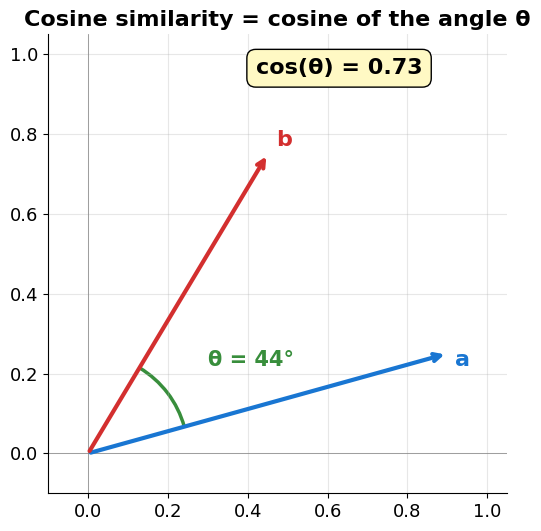

In [8]:
# One clean picture: the angle theta between two vectors IS the cosine similarity.
fig, ax = plt.subplots(figsize=(6.0, 5.5))
a = np.array([0.90, 0.25])
b = np.array([0.45, 0.75])
cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
theta = np.degrees(np.arccos(cos))

ax.annotate('', xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#1976d2'))
ax.annotate('', xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#d32f2f'))
arc = mpatches.Arc((0, 0), 0.5, 0.5, angle=0,
                   theta1=np.degrees(np.arctan2(a[1], a[0])),
                   theta2=np.degrees(np.arctan2(b[1], b[0])), color='#388e3c', lw=2.5)
ax.add_patch(arc)
ax.text(0.30, 0.22, f'θ = {theta:.0f}°', fontsize=15, color='#388e3c', fontweight='bold')
ax.text(a[0] + 0.02, a[1] - 0.03, 'a', fontsize=16, fontweight='bold', color='#1976d2')
ax.text(b[0] + 0.02, b[1] + 0.02, 'b', fontsize=16, fontweight='bold', color='#d32f2f')
ax.text(0.42, 0.95, f'cos(θ) = {cos:.2f}', fontsize=16, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff9c4'))

ax.set_xlim(-0.1, 1.05)
ax.set_ylim(-0.1, 1.05)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Cosine similarity = cosine of the angle θ', fontweight='bold')
plt.tight_layout()
plt.show()

### What the number actually means

Same reference vector, swept from 0° to 180°. Cosine **starts at 1** (identical direction), is **0** at a right angle, and reaches **−1** when the vectors point opposite ways.

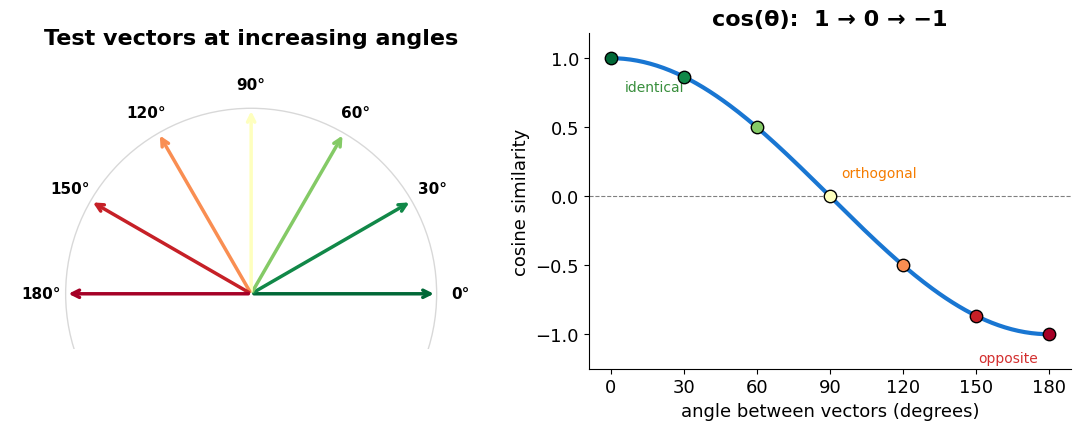

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
cmap = plt.cm.RdYlGn
angles = [0, 30, 60, 90, 120, 150, 180]

# Left: a fan of test vectors at increasing angles from the x-axis
for ang in angles:
    r = np.radians(ang)
    v = np.array([np.cos(r), np.sin(r)])
    c = cmap((np.cos(r) + 1) / 2)            # map cos in [-1, 1] -> colour in [0, 1]
    ax1.annotate('', xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=2.5, color=c))
    ax1.text(v[0] * 1.13, v[1] * 1.13, f'{ang}°', ha='center', va='center', fontsize=11, fontweight='bold')
ax1.add_patch(plt.Circle((0, 0), 1, fill=False, color='gray', alpha=0.3))
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-0.3, 1.3)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Test vectors at increasing angles', fontweight='bold')

# Right: cosine as a function of the angle
deg = np.linspace(0, 180, 200)
ax2.plot(deg, np.cos(np.radians(deg)), color='#1976d2', lw=3)
for ang in angles:
    ax2.scatter(ang, np.cos(np.radians(ang)), s=80, zorder=5, edgecolors='black',
                color=cmap((np.cos(np.radians(ang)) + 1) / 2))
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_xticks(angles)
ax2.set_ylim(-1.25, 1.18)   # headroom below the curve so 'opposite' clears the line
ax2.set_xlabel('angle between vectors (degrees)')
ax2.set_ylabel('cosine similarity')
ax2.set_title('cos(θ):  1 → 0 → −1', fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
# Keep each label off the blue curve: identical sits below-right of (0,1),
# orthogonal above-right of (90,0), opposite below-left of (180,-1).
ax2.annotate('identical',  (0, 1),    textcoords='offset points', xytext=(10, -16), ha='left',  va='top',    fontsize=10, color='#388e3c')
ax2.annotate('orthogonal', (90, 0),   textcoords='offset points', xytext=(8, 12),   ha='left',  va='bottom', fontsize=10, color='#f57c00')
ax2.annotate('opposite',   (180, -1), textcoords='offset points', xytext=(-8, -12), ha='right', va='top',    fontsize=10, color='#d32f2f')
plt.tight_layout()
plt.show()

### Cosine on movie-like vectors: three cases

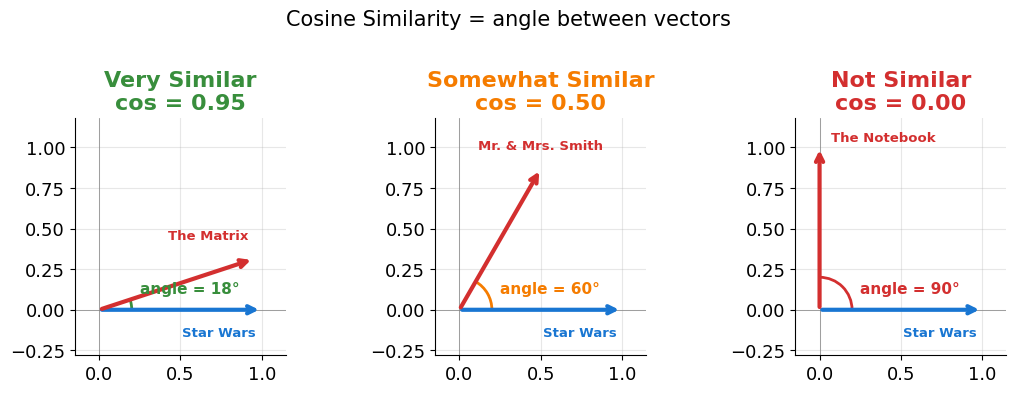

In [10]:
# Three "textbook" cases -- pick vectors so the cosine actually hits the labeled values.
# a is the same reference movie in every case; b is rotated to hit cos = 0.95, 0.50, 0.00,
# and each b is a real movie whose similarity to the reference matches that angle.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))

a = np.array([1.0, 0.0])
ref_movie = 'Star Wars'                        # vector a -- same reference in all three panels
target_cos = [0.95, 0.50, 0.00]
# (case label, colour, movie for b, b-label offset in points, b-label h-align)
case_meta = [
    ('Very Similar',     '#388e3c', 'The Matrix',       (-4, 12), 'right'),
    ('Somewhat Similar', '#f57c00', 'Mr. & Mrs. Smith', (0, 12),  'center'),
    ('Not Similar',      '#d32f2f', 'The Notebook',     (8, 2),   'left'),
]

for ax, target, (label, color, b_movie, b_off, b_ha) in zip(axes, target_cos, case_meta):
    theta = np.arccos(target)
    b = np.array([np.cos(theta), np.sin(theta)])
    cos = float(np.dot(a, b))   # equals target by construction

    ax.annotate('', xy=a, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#1976d2'))
    ax.annotate('', xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#d32f2f'))

    angle_a = np.degrees(np.arctan2(a[1], a[0]))
    angle_b = np.degrees(np.arctan2(b[1], b[0]))
    arc = mpatches.Arc((0, 0), 0.4, 0.4, angle=0,
                       theta1=min(angle_a, angle_b), theta2=max(angle_a, angle_b),
                       color=color, lw=2)
    ax.add_patch(arc)
    ax.text(0.25, 0.10, f'angle = {np.degrees(theta):.0f}°',
            color=color, fontsize=11, fontweight='bold')

    # Label the arrows with real movie names instead of 'a' / 'b'.
    ax.annotate(ref_movie, xy=a, xytext=(-4, -12), textcoords='offset points',
                ha='right', va='top', fontsize=9.5, fontweight='bold', color='#1976d2')
    ax.annotate(b_movie, xy=b, xytext=b_off, textcoords='offset points',
                ha=b_ha, va='bottom', fontsize=9.5, fontweight='bold', color='#d32f2f')
    ax.set_title(f'{label}\ncos = {cos:.2f}', fontweight='bold', color=color)
    ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.28, 1.18); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', lw=0.5)
    ax.axvline(x=0, color='gray', lw=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Cosine Similarity = angle between vectors', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Euclidean Distance = the straight-line gap

**Algebraic form** (works in any number of dimensions):

$$d(\vec{a},\vec{b}) \;=\; \sqrt{\sum_i (a_i - b_i)^2}$$

Forget angles — just measure the **distance between the two points**.

Small distance = similar.

(As a *similarity* score we often use $-d$, since closer should mean "more similar".)

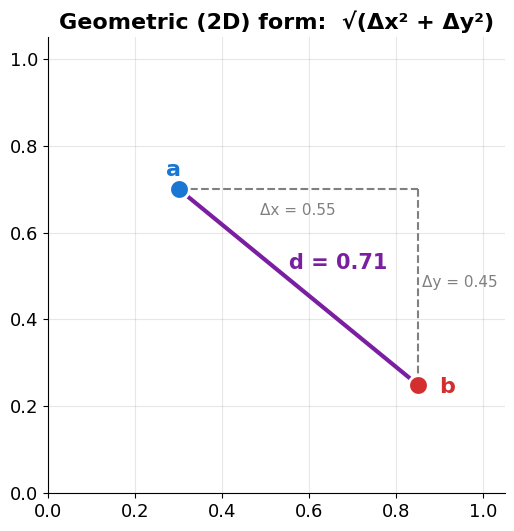

In [11]:
# Euclidean distance is just Pythagoras on the difference vector.
fig, ax = plt.subplots(figsize=(6.5, 5.5))
a = np.array([0.30, 0.70])
b = np.array([0.85, 0.25])
d = np.linalg.norm(a - b)

ax.scatter(*a, s=200, color='#1976d2', zorder=5, edgecolors='white', linewidth=2)
ax.scatter(*b, s=200, color='#d32f2f', zorder=5, edgecolors='white', linewidth=2)
ax.plot([a[0], b[0]], [a[1], b[1]], color='#7b1fa2', lw=3)              # hypotenuse = distance
ax.plot([a[0], b[0]], [a[1], a[1]], ls='--', color='gray', lw=1.5)     # horizontal leg
ax.plot([b[0], b[0]], [a[1], b[1]], ls='--', color='gray', lw=1.5)     # vertical leg
ax.text((a[0] + b[0]) / 2 - 0.02, (a[1] + b[1]) / 2 + 0.04, f'd = {d:.2f}',
        color='#7b1fa2', fontsize=15, fontweight='bold')
ax.text((a[0] + b[0]) / 2, a[1] - 0.06, f'Δx = {abs(a[0] - b[0]):.2f}', color='gray', fontsize=11, ha='center')
ax.text(b[0] + 0.01, (a[1] + b[1]) / 2, f'Δy = {abs(a[1] - b[1]):.2f}', color='gray', fontsize=11)
ax.text(a[0] - 0.03, a[1] + 0.03, 'a', color='#1976d2', fontsize=16, fontweight='bold')
ax.text(b[0] + 0.05, b[1] - 0.02, 'b', color='#d32f2f', fontsize=16, fontweight='bold')

ax.set_title('Geometric (2D) form:  √(Δx² + Δy²)', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Manhattan Distance = the city-block path

$$d_{1}(\vec{a},\vec{b}) \;=\; \sum_i |a_i - b_i|$$

Instead of the diagonal hypotenuse, **sum the absolute differences** — as if you can only walk along the grid, N/S or E/W. Manhattan ≥ Euclidean always (the diagonal is shorter than the L-shape).

In **high-dimensional, sparse** vectors (where most coordinates are zero) L1 is often the more robust choice for nearest-neighbour search — no squaring means fewer dimensions dominate the score.

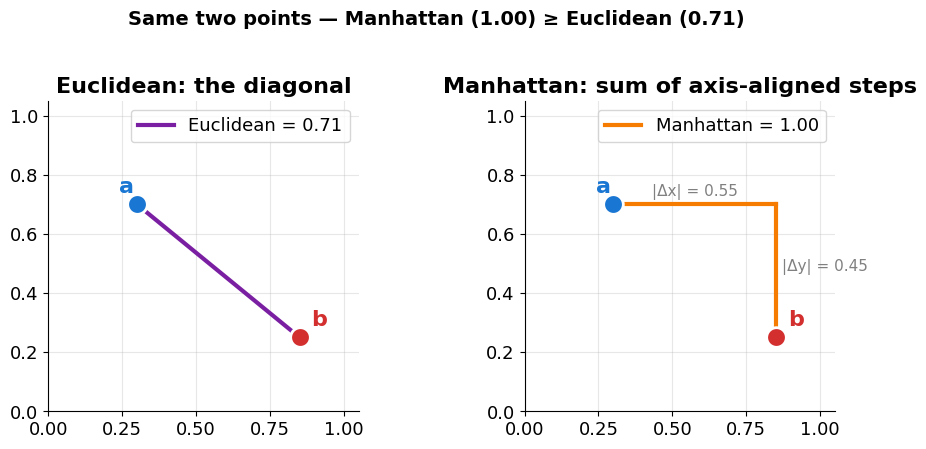

Manhattan = L1 norm of (a - b); Euclidean = L2. In high-D, L1 is often the more robust choice.


In [12]:
# Same two points as the Euclidean slide — but here we walk the grid (no diagonal shortcut).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.4))

a = np.array([0.30, 0.70])
b = np.array([0.85, 0.25])
euc = np.linalg.norm(a - b)
man = np.abs(a - b).sum()

# (1) Euclidean — the diagonal, for reference.
ax1.scatter(*a, s=200, color='#1976d2', zorder=5, edgecolors='white', linewidth=2)
ax1.scatter(*b, s=200, color='#d32f2f', zorder=5, edgecolors='white', linewidth=2)
ax1.plot([a[0], b[0]], [a[1], b[1]], color='#7b1fa2', lw=3, label=f'Euclidean = {euc:.2f}')
ax1.text(a[0] - 0.06, a[1] + 0.04, 'a', color='#1976d2', fontsize=16, fontweight='bold')
ax1.text(b[0] + 0.04, b[1] + 0.04, 'b', color='#d32f2f', fontsize=16, fontweight='bold')
ax1.set_title('Euclidean: the diagonal', fontweight='bold')
ax1.set_xlim(0, 1.05); ax1.set_ylim(0, 1.05); ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3); ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(loc='upper right')

# (2) Manhattan — two axis-aligned legs whose lengths add up to |Δx| + |Δy|.
ax2.scatter(*a, s=200, color='#1976d2', zorder=5, edgecolors='white', linewidth=2)
ax2.scatter(*b, s=200, color='#d32f2f', zorder=5, edgecolors='white', linewidth=2)
ax2.plot([a[0], b[0]], [a[1], a[1]], color='#f57c00', lw=3)
ax2.plot([b[0], b[0]], [a[1], b[1]], color='#f57c00', lw=3, label=f'Manhattan = {man:.2f}')
ax2.text(a[0] - 0.06, a[1] + 0.04, 'a', color='#1976d2', fontsize=16, fontweight='bold')
ax2.text(b[0] + 0.04, b[1] + 0.04, 'b', color='#d32f2f', fontsize=16, fontweight='bold')
ax2.text((a[0] + b[0]) / 2, a[1] + 0.03, f'|Δx| = {abs(a[0] - b[0]):.2f}',
         color='gray', ha='center', fontsize=11)
ax2.text(b[0] + 0.02, (a[1] + b[1]) / 2, f'|Δy| = {abs(a[1] - b[1]):.2f}',
         color='gray', fontsize=11)
ax2.set_title('Manhattan: sum of axis-aligned steps', fontweight='bold')
ax2.set_xlim(0, 1.05); ax2.set_ylim(0, 1.05); ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3); ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(loc='upper right')

plt.suptitle(f'Same two points — Manhattan ({man:.2f}) ≥ Euclidean ({euc:.2f})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Manhattan = L1 norm of (a - b); Euclidean = L2. In high-D, L1 is often the more robust choice.')


---
## Summary: Cosine vs. Euclidean vs. Dot Product vs. Manhattan

Same three vectors (a, b1, and b2 = 2·b1), four different verdicts on "which of b1 or b2 is closer to a?"


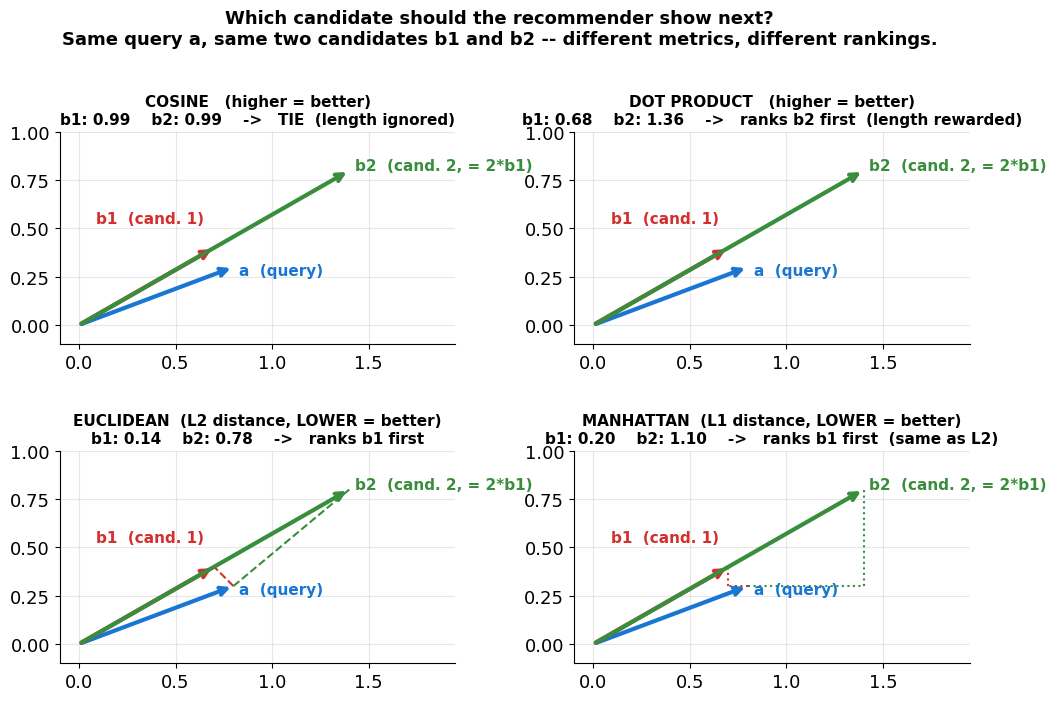

In [13]:
# Setup: a is the QUERY (e.g. a movie the user just liked); b1, b2 are two CANDIDATES
# in the catalog. The recommender must rank them. Each metric scores (a, candidate)
# and the candidate with the better score is shown first. b2 = 2*b1 -- same DIRECTION
# as b1 but twice as LONG (think: more tags, more ratings, longer description).
fig, axes = plt.subplots(2, 2, figsize=(10, 7.0))

a  = np.array([0.8, 0.3])   # query
b1 = np.array([0.7, 0.4])   # candidate 1
b2 = 2 * b1                 # candidate 2 -- same direction, twice as long


def draw_vectors(ax, title, extras=None):
    ax.annotate('', xy=a,  xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#1976d2'))
    ax.annotate('', xy=b1, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#d32f2f'))
    ax.annotate('', xy=b2, xytext=(0, 0), arrowprops=dict(arrowstyle='->', lw=3, color='#388e3c'))
    ax.text(a[0]  + 0.03, a[1] - 0.04, 'a  (query)',
            color='#1976d2', fontweight='bold', fontsize=11)
    # b1 label sits up-left of its arrowhead so it doesn't land on the collinear b2 arrow.
    ax.text(b1[0] - 0.05, b1[1] + 0.11, 'b1  (cand. 1)',
            color='#d32f2f', fontweight='bold', fontsize=11, ha='right', va='bottom')
    ax.text(b2[0] + 0.03, b2[1],       'b2  (cand. 2, = 2*b1)',
            color='#388e3c', fontweight='bold', fontsize=11)
    if extras: extras(ax)
    ax.set_title(title, fontweight='bold', fontsize=11, loc='center')
    ax.set_xlim(-0.1, 1.95); ax.set_ylim(-0.1, 1.0); ax.set_aspect('equal')
    ax.grid(True, alpha=0.3); ax.spines[['top', 'right']].set_visible(False)


cos1 = np.dot(a, b1) / (np.linalg.norm(a) * np.linalg.norm(b1))
cos2 = np.dot(a, b2) / (np.linalg.norm(a) * np.linalg.norm(b2))
draw_vectors(axes[0, 0],
             f'COSINE   (higher = better)\n'
             f'b1: {cos1:.2f}    b2: {cos2:.2f}    ->   TIE  (length ignored)')

dot1 = np.dot(a, b1); dot2 = np.dot(a, b2)
draw_vectors(axes[0, 1],
             f'DOT PRODUCT   (higher = better)\n'
             f'b1: {dot1:.2f}    b2: {dot2:.2f}    ->   ranks b2 first  (length rewarded)')

euc1 = np.linalg.norm(a - b1); euc2 = np.linalg.norm(a - b2)
def euc_extras(ax):
    ax.plot([a[0], b1[0]], [a[1], b1[1]], '--', color='#d32f2f', lw=1.5)
    ax.plot([a[0], b2[0]], [a[1], b2[1]], '--', color='#388e3c', lw=1.5)
draw_vectors(axes[1, 0],
             f'EUCLIDEAN  (L2 distance, LOWER = better)\n'
             f'b1: {euc1:.2f}    b2: {euc2:.2f}    ->   ranks b1 first',
             extras=euc_extras)

man1 = np.abs(a - b1).sum(); man2 = np.abs(a - b2).sum()
def man_extras(ax):
    for b_, c_ in [(b1, '#d32f2f'), (b2, '#388e3c')]:
        ax.plot([a[0], b_[0]], [a[1], a[1]], color=c_, ls=':', lw=1.5)
        ax.plot([b_[0], b_[0]], [a[1], b_[1]], color=c_, ls=':', lw=1.5)
draw_vectors(axes[1, 1],
             f'MANHATTAN  (L1 distance, LOWER = better)\n'
             f'b1: {man1:.2f}    b2: {man2:.2f}    ->   ranks b1 first  (same as L2)',
             extras=man_extras)

plt.suptitle('Which candidate should the recommender show next?\n'
             'Same query a, same two candidates b1 and b2 -- different metrics, different rankings.',
             fontsize=13, y=0.99, fontweight='bold')
fig.subplots_adjust(left=0.06, right=0.97, top=0.82, bottom=0.05, wspace=0.30, hspace=0.45)
plt.show()

### When to use which measure

| Measure | Best for | Why |
|---|---|---|
| **Cosine** | text, tags, bag-of-words — anywhere **lengths vary** | only angle counts, so a 10-word and a 1000-word doc compare fairly |
| **Dot product** | recommender scores (e.g. matrix factorisation) | rewards **both** alignment and confidence/length |
| **Euclidean (L2)** | dense vectors where **magnitude is meaningful** | straight-line gap; squaring amplifies large differences |
| **Manhattan (L1)** | high-dim **sparse, non-learned** vectors (raw TF-IDF, counts) | no squaring, so fewer single dims dominate — a *rule of thumb* (Aggarwal et al. 2001), not a law |

**Pick the metric by where the vectors came from — not by their dimensionality:**

- **Learned embeddings** (sentence transformers, …) → use the metric they were *trained* with, almost always **cosine / dot** — at 384 *or* 4096 dims. Don't switch to L1 just because it's high-dimensional.
- **Sparse, non-learned** vectors (TF-IDF, counts) → **cosine**; L1 is worth a try in very high dimensions.

**Normalise and the distinction often vanishes:** for unit vectors $\lVert\vec a-\vec b\rVert_2^2 = 2 - 2(\vec a\cdot\vec b)$, so cosine, dot product, and Euclidean rank neighbours in the **identical** order.

## The Curse of Dimensionality

Genre vectors live in ~20 dimensions; real feature vectors can have **thousands**. As dimensionality grows, something counter-intuitive happens to distance.

**The phenomenon.** Beyer et al. (1999) proved that for a wide class of distributions, as $d \to \infty$ the ratio of the **farthest** to the **nearest** neighbour of a query point tends to $1$. In very high dimensions *every* point is roughly the same distance from every other point — so "nearest neighbour" loses its meaning.

**Geometric intuition.** Fix the unit cube $[0,1]^d$. Two things happen as $d$ grows:

- The inscribed unit ball's volume shrinks toward $0$ — almost all the cube's mass sits **in the corners**, not near the centre.
- Almost all of a $d$-ball's volume concentrates in a **thin shell** at the boundary, so two random points have nearly the same radius and their pairwise distances bunch into a narrow band.

**Why cosine survives better — with caveats.** Cosine isn't immune: for **dense** random vectors in high $d$, every pair becomes nearly orthogonal (cos $\approx$ 0) and the curse hits it too. But the vectors used in content-based recommending — TF-IDF, tag indicators, one-hot features — are **sparse**: similarity is driven by the handful of dimensions where both vectors are non-zero. That handful carries the signal; the many shared zeros are silent (they neither add to the numerator nor distort the angle), whereas in Euclidean distance every dimension contributes a small `0−ε` term and the noise piles up. Discarding magnitude also removes one source of variation that carries no meaning for count-style vectors.

> 📚 *Sources:* Beyer, Goldstein, Ramakrishnan & Shaft (1999), *When Is "Nearest Neighbor" Meaningful?* (ICDT); Aggarwal, Hinneburg & Keim (2001), *On the Surprising Behavior of Distance Metrics in High Dimensional Space*.

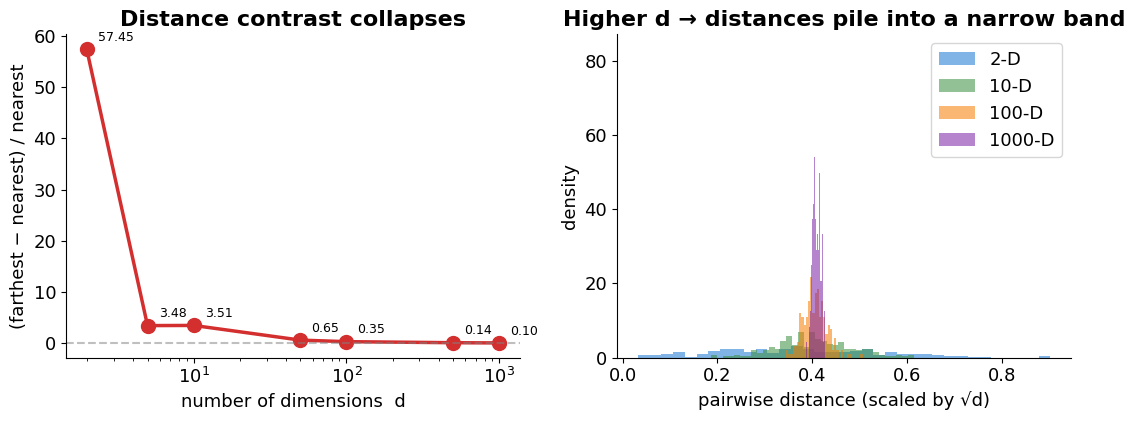

At d = 1000, every pair of points is essentially the same distance apart — "nearest neighbour" no longer means anything.


In [14]:
# Two panels show the same phenomenon from two angles:
# (1) the contrast (farthest − nearest)/nearest crashes toward 0 as d grows,
# (2) the distribution of pairwise distances piles into a narrow band — so "near" and "far"
#     become indistinguishable. No need for a 3-D scatter; the histogram tells the story.
rng = np.random.default_rng(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

# (1) Distance contrast vs dimensionality.
dims = [2, 5, 10, 50, 100, 500, 1000]
contrast = []
for d in dims:
    X = rng.random((300, d))
    dist = np.linalg.norm(X[1:] - X[0], axis=1)
    contrast.append((dist.max() - dist.min()) / dist.min())
ax1.plot(dims, contrast, 'o-', color='#d32f2f', lw=2.5, markersize=10)
for d, c in zip(dims, contrast):
    ax1.annotate(f'{c:.2f}', (d, c), textcoords='offset points', xytext=(8, 6), fontsize=9)
ax1.set_xscale('log')
ax1.set_xlabel('number of dimensions  d')
ax1.set_ylabel('(farthest − nearest) / nearest')
ax1.set_title('Distance contrast collapses', fontweight='bold')
ax1.axhline(0, color='gray', ls='--', alpha=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# (2) Pairwise distance distribution at d = 2 → 10 → 100 → 1000.
# Scale by √d so curves overlap and we can visually compare *widths* (spread shrinks).
for d, color, label in [(2, '#1976d2', '2-D'), (10, '#388e3c', '10-D'),
                        (100, '#f57c00', '100-D'), (1000, '#7b1fa2', '1000-D')]:
    Y = rng.random((400, d))
    dd = np.linalg.norm(Y[:200] - Y[200:], axis=1) / np.sqrt(d)
    ax2.hist(dd, bins=35, alpha=0.55, color=color, label=label, density=True)
ax2.set_xlabel('pairwise distance (scaled by √d)')
ax2.set_ylabel('density')
ax2.set_title('Higher d → distances pile into a narrow band', fontweight='bold')
ax2.legend(loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print('At d = 1000, every pair of points is essentially the same distance apart — '
      '"nearest neighbour" no longer means anything.')


## Beyond hand-crafted features

So far every feature has been **hand-designed** — genres, plus the richer columns we sketched (cast, keywords, decade, popularity). Someone has to choose them, label them, and keep them updated. That does not scale.

The real power: turn **any** data into a vector automatically — then reuse the *exact same* similarity tools.

| Data | How it becomes a vector |
|---|---|
| **Text** | bag-of-words / TF-IDF → word & sentence embeddings |
| **Images** | pixel features → CNN embeddings |
| **Tabular** | the columns already *are* the vector |
| **Anything** | a learned embedding model |

Once everything is a vector, *similarity is similarity*.

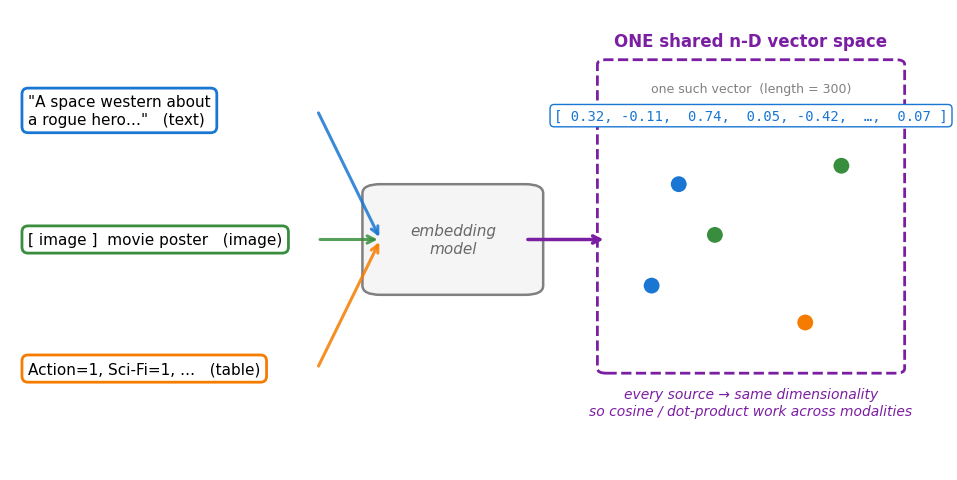

In [15]:
# Schematic: three very different data types embed into ONE shared n-D space.
# Each modality has its own arrow INTO the embedding model; one arrow comes OUT
# of the model and points into the shared vector space.
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Three input sources (left column).
sources = [
    ('"A space western about\na rogue hero…"   (text)', 0.02, 0.78, '#1976d2'),
    ('[ image ]  movie poster   (image)',              0.02, 0.50, '#388e3c'),
    ('Action=1, Sci-Fi=1, …   (table)',                0.02, 0.22, '#f57c00'),
]
for txt, x, y, c in sources:
    ax.text(x, y, txt, fontsize=11, va='center', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=c, lw=2))

# Embedding model box — single shared transformer.
box_x, box_y, box_w, box_h = 0.41, 0.40, 0.16, 0.20
ax.add_patch(mpatches.FancyBboxPatch((box_x, box_y), box_w, box_h, boxstyle='round,pad=0.02',
                                     facecolor='#f5f5f5', edgecolor='gray', lw=1.8))
ax.text(box_x + box_w / 2, box_y + box_h / 2, 'embedding\nmodel',
        fontsize=11, style='italic', color='dimgray', ha='center', va='center')

# Three arrows: each source -> LEFT edge of the box (so they clearly enter the model).
box_left = box_x
for _, x, y, c in sources:
    ax.annotate('', xy=(box_left, box_y + box_h / 2),
                xytext=(x + 0.32, y),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.2, alpha=0.85))

# One arrow OUT of the box -> into the shared vector space.
ax.annotate('', xy=(0.66, box_y + box_h / 2),
            xytext=(box_x + box_w, box_y + box_h / 2),
            arrowprops=dict(arrowstyle='->', color='#7b1fa2', lw=2.5))

# Shared vector space — dashed-purple frame, scatter of points.
ax.add_patch(mpatches.FancyBboxPatch((0.66, 0.22), 0.32, 0.66, boxstyle='round,pad=0.01',
                                     facecolor='none', edgecolor='#7b1fa2', lw=2, ls='--'))
ax.text(0.82, 0.92, 'ONE shared n-D vector space', fontsize=12, fontweight='bold',
        color='#7b1fa2', ha='center')

pts = np.array([[0.74, 0.62], [0.78, 0.51], [0.88, 0.32], [0.71, 0.40], [0.92, 0.66]])
cols = ['#1976d2', '#388e3c', '#f57c00', '#1976d2', '#388e3c']
ax.scatter(pts[:, 0], pts[:, 1], s=180, c=cols, edgecolors='white', linewidth=2, zorder=4)

# Example vector right under the title.
ax.text(0.82, 0.82, 'one such vector  (length = 300)', fontsize=9, color='gray', ha='center')
ax.text(0.82, 0.76, '[ 0.32, -0.11,  0.74,  0.05, -0.42,  …,  0.07 ]',
        fontsize=10, color='#1976d2', family='monospace', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#1976d2', lw=1))

# Caption sits BELOW the dashed frame.
ax.text(0.82, 0.12, 'every source → same dimensionality\n'
                    'so cosine / dot-product work across modalities',
        fontsize=10, color='#7b1fa2', ha='center', style='italic')

plt.tight_layout()
plt.show()

## Step 1: Bag-of-Words — count the words, drop the order

The simplest way to turn text into a vector: pick a **vocabulary**, then for every document count how often each vocabulary word appears.

| document | *space* | *rebels* | *empire* | *romance* | *iceberg* |
|---|---|---|---|---|---|
| "*space rebels fight an evil empire*"   | **1** | **1** | **1** | 0 | 0 |
| "*a romance about a doomed ocean liner that hits an iceberg*" | 0 | 0 | 0 | **1** | **1** |

Every row is now a vector in vocabulary space — and cosine similarity works exactly as before.

**Catch:** "the", "a", "movie" dominate every row → cosine is mostly noise. We need to **down-weight common words** ⤵

## TF-IDF: turning text into vectors

**TF-IDF = Term Frequency × Inverse Document Frequency.** Bag-of-words just counts words; TF-IDF *weights* each count by how informative the word is.

$$\text{tfidf}(t,d) \;=\; \underbrace{\text{tf}(t,d)}_{\substack{\textbf{term frequency:} \\ \text{how often } t \\ \text{appears in doc } d}} \;\times\; \underbrace{\log \dfrac{N}{\text{df}(t)}}_{\substack{\textbf{inverse document frequency:} \\ N = \#\text{ docs in the corpus}, \\ \text{df}(t) = \#\text{ docs containing } t}}$$

- **df(t)** is the **document frequency** — how many of the *N* documents contain *t* at least once.
- Word in **every** doc → df = N → idf = log 1 = **0** (worthless).
- Word in **one** doc → df = 1 → idf = log N (most distinctive).

Then two documents are compared with the **same cosine similarity** as before.

**Practical note: smoothed idf.** scikit-learn (and most modern implementations) use a **smoothed** variant:

$$\text{idf}(t) \;=\; \log \dfrac{N+1}{\text{df}(t)+1} \;+\; 1$$

The `+1` in numerator and denominator pretends there is one extra document containing every term — so an unseen term (df = 0) does not divide by zero, and the trailing `+1` keeps even ubiquitous words from being fully zeroed out (they still get a small weight equal to their tf). Ranking behaviour is essentially the same; only the absolute weights differ. (We use the classical $\log(N/\text{df})$ form above because it makes the intuition cleaner.)


### Intuition: why "the" gets weight 0 and "wormhole" gets a huge one

Pick a tiny corpus of **N = 5** movie blurbs. For any word *t*:

- **tf**(t, d) — how often *t* appears in document *d*
- **df**(t)  — how many of the 5 documents contain *t* (its **doc-frequency**)
- **idf**(t) = $\log\bigl(N / df(t)\bigr)$ — **big** when *t* is rare, **0** when *t* is everywhere

| word | df | $\log(5/df)$ | verdict |
|---|---|---|---|
| *the*       | 5 | log(1)   = **0**     | killed — appears everywhere, useless |
| *romance*   | 2 | log(2.5) ≈ **0.92**  | discriminating — pairs the love stories |
| *wormhole*  | 1 | log(5)   ≈ **1.61**  | very informative — almost defines that doc |

So a word's weight = **how often it shows up here × how rare it is overall**. Multiply, and informative words dominate the vector.

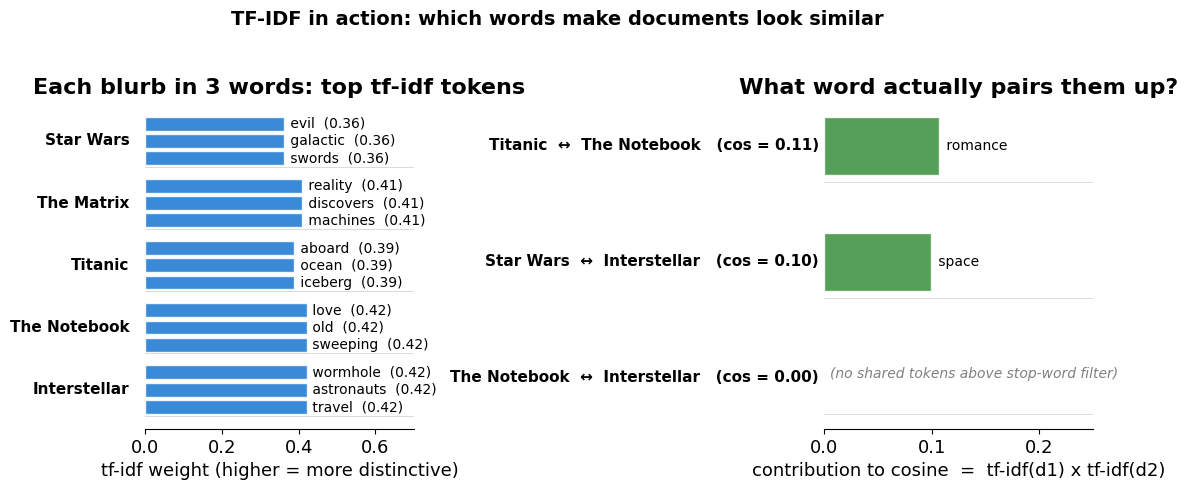

Romance pair drives Titanic ↔ Notebook; "space" pairs Star Wars and Interstellar. No genres needed.


In [16]:
# Five tiny movie blurbs and the words that drive their similarity.
# Left: each blurb's TOP weighted tokens (what makes that doc unique).
# Right: for the top-3 most-similar pairs, the SHARED words that actually create the score
#        -- so students see "why" Titanic ↔ The Notebook pair up (the word "romance"), etc.
from sklearn.feature_extraction.text import TfidfVectorizer

docs = {
    'Star Wars':    'space rebels fight an evil galactic empire with laser swords',
    'The Matrix':   'a hacker discovers reality is a simulation and fights machines',
    'Titanic':      'a romance aboard a doomed ocean liner that hits an iceberg',
    'The Notebook': 'a sweeping romance remembered by an old man still in love',
    'Interstellar': 'astronauts travel through space and a wormhole to save humanity',
}
titles = list(docs)
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(docs.values())
sim = cosine_similarity(X)
vocab = tfidf.get_feature_names_out()
W = X.toarray()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# (1) Top-3 tokens per document as horizontal bars (one panel of 5 small bar groups).
TOPK = 3
ypos = 0
for d_idx, title in enumerate(titles):
    weights = W[d_idx]
    top_ids = weights.argsort()[::-1][:TOPK]
    for r, j in enumerate(top_ids):
        ax1.barh(ypos, weights[j], color='#1976d2', alpha=0.85, edgecolor='white')
        ax1.text(weights[j] + 0.005, ypos, f' {vocab[j]}  ({weights[j]:.2f})',
                 va='center', fontsize=10)
        ypos += 1
    ax1.axhline(ypos - 0.5, color='gray', lw=0.5, alpha=0.4)
    ax1.text(-0.04, ypos - TOPK / 2 - 0.5, title, ha='right', va='center',
             fontsize=11, fontweight='bold')
    ypos += 0.6
ax1.set_xlim(0, 0.7)
ax1.set_xlabel('tf-idf weight (higher = more distinctive)')
ax1.set_title('Each blurb in 3 words: top tf-idf tokens', fontweight='bold')
ax1.set_yticks([])
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.invert_yaxis()

# (2) Shared words driving the TOP 3 pairs. Contribution = tfidf(w,d1) * tfidf(w,d2).
pairs = []
for i in range(len(titles)):
    for j in range(i + 1, len(titles)):
        pairs.append((sim[i, j], i, j))
pairs.sort(reverse=True)
ypos = 0
for s, i, j in pairs[:3]:
    contrib = W[i] * W[j]
    nz = np.where(contrib > 1e-6)[0]
    nz = nz[np.argsort(contrib[nz])[::-1]]
    pair_label = f'{titles[i]}  ↔  {titles[j]}   (cos = {s:.2f})'
    for k_, idx in enumerate(nz):
        ax2.barh(ypos, contrib[idx], color='#388e3c', alpha=0.85, edgecolor='white')
        ax2.text(contrib[idx] + 0.003, ypos, f' {vocab[idx]}',
                 va='center', fontsize=10)
        ypos += 1
    if len(nz) == 0:
        ax2.text(0.005, ypos, '(no shared tokens above stop-word filter)',
                 color='gray', fontsize=10, fontstyle='italic')
        ypos += 1
    ax2.text(-0.005, ypos - max(len(nz), 1) / 2 - 0.5, pair_label, ha='right', va='center',
             fontsize=11, fontweight='bold')
    ax2.axhline(ypos - 0.5, color='gray', lw=0.5, alpha=0.4)
    ypos += 0.6
ax2.set_xlim(0, 0.25)
ax2.set_xlabel('contribution to cosine  =  tf-idf(d1) x tf-idf(d2)')
ax2.set_title('What word actually pairs them up?', fontweight='bold')
ax2.set_yticks([])
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.invert_yaxis()

plt.suptitle('TF-IDF in action: which words make documents look similar',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Romance pair drives Titanic ↔ Notebook; "space" pairs Star Wars and Interstellar. No genres needed.')


---
## Live Demo: TF-IDF in action — "Because you liked..."

The same trick on real MovieLens data: take a richer item vector (genres + tags + decade + popularity, all weighted with TF-IDF) and use cosine similarity to find the nearest — and **furthest** — neighbours.


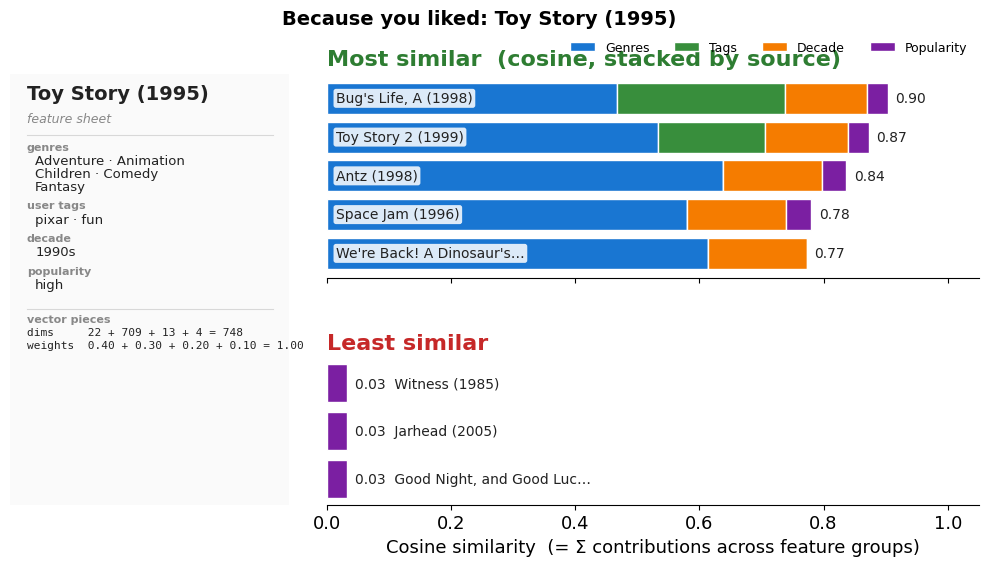

In [17]:
import warnings
# Richer item vector: combine FOUR feature sources, all TF-IDF + L2-normalised,
# then concatenated with per-source weights that SUM TO 1.00:
#   genres (rare combos weighted), user tags (theme/style),
#   release decade (era), popularity bucket (blockbuster vs niche).
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import scipy.sparse as sp

tags_df = pd.read_csv('ml-latest-small/tags.csv')
tag_text = (tags_df.groupby('movieId')['tag']
            .apply(lambda s: ' '.join(s.astype(str).str.lower())))

Xg = TfidfVectorizer(token_pattern=r'[^ ]+').fit_transform(
    movies['genres'].str.replace('|', ' ', regex=False).str.lower())
Xt = TfidfVectorizer(stop_words='english', min_df=2, max_features=2000,
                     token_pattern=r'[a-z][a-z\-]+').fit_transform(
    movies['movieId'].map(tag_text).fillna(''))
year = pd.to_numeric(movies['title'].str.extract(r'\((\d{4})\)', expand=False), errors='coerce')
decade_str = (year // 10 * 10).fillna(-1).astype(int).astype(str)
Xy = TfidfVectorizer(token_pattern=r'[^ ]+').fit_transform(decade_str)
rcount = ratings.groupby('movieId').size()
pop = pd.qcut(movies['movieId'].map(rcount).fillna(0), q=4,
              duplicates='drop', labels=['lo', 'midlo', 'midhi', 'hi'])
Xp = TfidfVectorizer(token_pattern=r'[^ ]+').fit_transform(pop.astype(str))

# L2-normalise each source, concatenate with weights summing to 1.
Xg_n, Xt_n, Xy_n, Xp_n = (normalize(M) for M in (Xg, Xt, Xy, Xp))
WEIGHTS = {'Genres': 0.40, 'Tags': 0.30, 'Decade': 0.20, 'Popularity': 0.10}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'WEIGHTS should sum to 1.00'

PARTS = [('Genres', Xg_n), ('Tags', Xt_n),
         ('Decade', Xy_n), ('Popularity', Xp_n)]
DIMS = {name: M.shape[1] for name, M in PARTS}
TOTAL_DIM = sum(DIMS.values())

feature_matrix = sp.hstack(
    [WEIGHTS[name] * M for name, M in PARTS]).tocsr()
# Per-row norms vary because some movies are missing tags or popularity buckets,
# so a piece can be the zero vector instead of unit-normalized.
ROW_NORMS = np.sqrt(np.asarray(
    feature_matrix.multiply(feature_matrix).sum(axis=1)).ravel())
sim_matrix = cosine_similarity(feature_matrix)

movies['_tags']   = movies['movieId'].map(tag_text).fillna('')
movies['_decade'] = decade_str.values
movies['_popbkt'] = pop.astype(str).values

# Bar-stack colors only -- the feature sheet itself stays monochrome.
SOURCE_COLORS = {'Genres': '#1976d2', 'Tags': '#388e3c',
                 'Decade': '#f57c00', 'Popularity': '#7b1fa2'}


def _group_contribs(i, j):
    """Cosine(i,j) split per feature group; pieces sum to cosine(i,j).

    cos(i,j) = sum_k w_k^2 * <Xk_i, Xk_j>  /  (||row_i|| * ||row_j||)
    so each piece's contribution = w_k^2 * <Xk_i, Xk_j> / (||row_i|| * ||row_j||).
    """
    denom = ROW_NORMS[i] * ROW_NORMS[j]
    if denom == 0:
        return {name: 0.0 for name, _ in PARTS}
    parts = {}
    for name, M in PARTS:
        inner = (M[i] @ M[j].T).toarray().ravel()[0]
        parts[name] = WEIGHTS[name]**2 * inner / denom
    return parts


def _wrap_words(words, max_chars=26, sep=' · '):
    """Pack words into lines of <= max_chars characters, joined by `sep`."""
    lines, line = [], ''
    for w in words:
        test = line + (sep if line else '') + w
        if len(test) > max_chars and line:
            lines.append(line); line = w
        else:
            line = test
    if line:
        lines.append(line)
    return lines


def show_similar(movie_title, n_top=5, n_bottom=3):
    """Tidy feature sheet (LEFT) + most/least similar bars (RIGHT).
    Feature sheet is monochrome with a clean type hierarchy.
    Bars stack contributions by source so students see WHY each pair matches."""
    match = movies[movies['title'].str.contains(movie_title, case=False, regex=False)]
    idx = match.index[0]
    row = movies.loc[idx]
    sims = pd.Series(sim_matrix[idx], index=movies.index)
    top = sims.sort_values(ascending=False).iloc[1:n_top + 1]
    bot = sims[sims > 0].sort_values(ascending=True).iloc[:n_bottom]

    fig = plt.figure(figsize=(12.5, 5.6))
    # wspace tight: bar y-labels live INSIDE the bars now, no gap needed.
    gs = fig.add_gridspec(2, 2, width_ratios=[0.30, 0.70],
                          height_ratios=[n_top, n_bottom + 0.6],
                          wspace=0.08, hspace=0.45)

    # ============================ LEFT: tidy feature sheet ============================
    ax_l = fig.add_subplot(gs[:, 0])
    ax_l.set_xlim(0, 1); ax_l.set_ylim(0, 1); ax_l.axis('off')
    ax_l.add_patch(mpatches.FancyBboxPatch(
        (0.0, 0.0), 1.0, 1.0, boxstyle='round,pad=0.02',
        facecolor='#fafafa', edgecolor='#cfcfcf', lw=1.0, zorder=0))

    # Big headline = the movie title (the query). One unified colour throughout.
    BODY = '#222'
    MUTED = '#888'
    y = 0.94
    ax_l.text(0.06, y, row['title'], fontsize=14, fontweight='bold', color=BODY)
    y -= 0.052
    ax_l.text(0.06, y, 'feature sheet', fontsize=9, color=MUTED, style='italic')
    y -= 0.030
    ax_l.plot([0.06, 0.94], [y, y], color='#d8d8d8', lw=0.8)
    y -= 0.035

    # Body = all keywords, one consistent small style with tiny section labels.
    genres = [g for g in row['genres'].split('|') if g != '(no genres listed)']
    tag_list = [t for t in row['_tags'].split() if t]
    top_tags = pd.Series(tag_list).value_counts().head(8).index.tolist() if tag_list else []
    decade_label = (row['_decade'] + 's') if row['_decade'].isdigit() else 'unknown'
    pop_label = {'lo': 'low', 'midlo': 'mid-low', 'midhi': 'mid-high',
                 'hi': 'high'}.get(row['_popbkt'], row['_popbkt'])

    sections = [
        ('genres',     genres if genres else ['—']),
        ('user tags',  top_tags if top_tags else ['—']),
        ('decade',     [decade_label]),
        ('popularity', [pop_label]),
    ]
    for label, vals in sections:
        ax_l.text(0.06, y, label, fontsize=8, color=MUTED,
                  fontweight='bold')
        y -= 0.033
        for ln in _wrap_words(vals):
            ax_l.text(0.09, y, ln, fontsize=9.5, color=BODY)
            y -= 0.030
        y -= 0.013

    # Caption (medium) sits IMMEDIATELY below the keyword body -- no big gap.
    y -= 0.005
    ax_l.plot([0.06, 0.94], [y, y], color='#d8d8d8', lw=0.8)
    y -= 0.030
    ax_l.text(0.06, y, 'vector pieces', fontsize=8, color=MUTED, fontweight='bold')
    pieces_str = ' + '.join(f'{DIMS[n]}' for n, _ in PARTS)
    y -= 0.030
    ax_l.text(0.06, y, f'dims     {pieces_str} = {TOTAL_DIM:,}',
              fontsize=8, color=BODY, family='monospace')
    weights_str = ' + '.join(f'{WEIGHTS[n]:.2f}' for n, _ in PARTS)
    y -= 0.030
    ax_l.text(0.06, y, f'weights  {weights_str} = 1.00',
              fontsize=8, color=BODY, family='monospace')

    # ============================ RIGHT: stacked bars =================================
    def stacked_bars(ax, indices, title, header_color, with_legend=False):
        # Short titles -- inline labels mean we need to fit ~22 chars inside the bar.
        labels = [(movies.loc[i, 'title'][:24] + '…') if len(movies.loc[i, 'title']) > 24
                  else movies.loc[i, 'title'] for i in indices]
        contribs = [_group_contribs(idx, j) for j in indices]
        ypos = np.arange(len(indices))
        left = np.zeros(len(indices))
        for name, _ in PARTS:
            vals = np.array([c[name] for c in contribs])
            ax.barh(ypos, vals, left=left, color=SOURCE_COLORS[name],
                    edgecolor='white', label=name if with_legend else None)
            left += vals
        # Inline movie labels: place INSIDE the bar when it's wide enough,
        # otherwise OUTSIDE to the right so a 0.03 bar doesn't get covered.
        for j, (lbl, total) in enumerate(zip(labels, left)):
            if total >= 0.20:
                ax.text(0.015, j, lbl, va='center', fontsize=10, color='#222', ha='left',
                        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none',
                                  boxstyle='round,pad=0.18'))
                ax.text(total + 0.012, j, f'{total:.2f}',
                        va='center', fontsize=10, color='#222')
            else:
                ax.text(total + 0.012, j, f'{total:.2f}  {lbl}',
                        va='center', fontsize=10, color='#222')
        ax.set_yticks([])
        ax.invert_yaxis()
        ax.set_xlim(0, max(1.05, left.max() * 1.18))
        ax.set_title(title, fontweight='bold', color=header_color, loc='left', pad=6)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='y', left=False)

    ax_t = fig.add_subplot(gs[0, 1])
    stacked_bars(ax_t, list(top.index), 'Most similar  (cosine, stacked by source)',
                 '#2e7d32', with_legend=True)
    ax_t.tick_params(axis='x', labelbottom=False)
    ax_t.legend(loc='lower right', fontsize=9, frameon=False, ncol=4,
                bbox_to_anchor=(1.0, 1.04))

    ax_b = fig.add_subplot(gs[1, 1], sharex=ax_t)
    stacked_bars(ax_b, list(bot.index), 'Least similar', '#c62828')
    ax_b.set_xlabel('Cosine similarity  (= Σ contributions across feature groups)')

    fig.suptitle(f'Because you liked: {row["title"]}', fontweight='bold',
                 fontsize=14, y=0.995)
    # ax_l uses axis('off'), which tight_layout flags as 'incompatible' --
    # but the manual rect gives the layout we want, so suppress the noise.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.show()


show_similar('Toy Story (1995)')


### …and for Forrest Gump


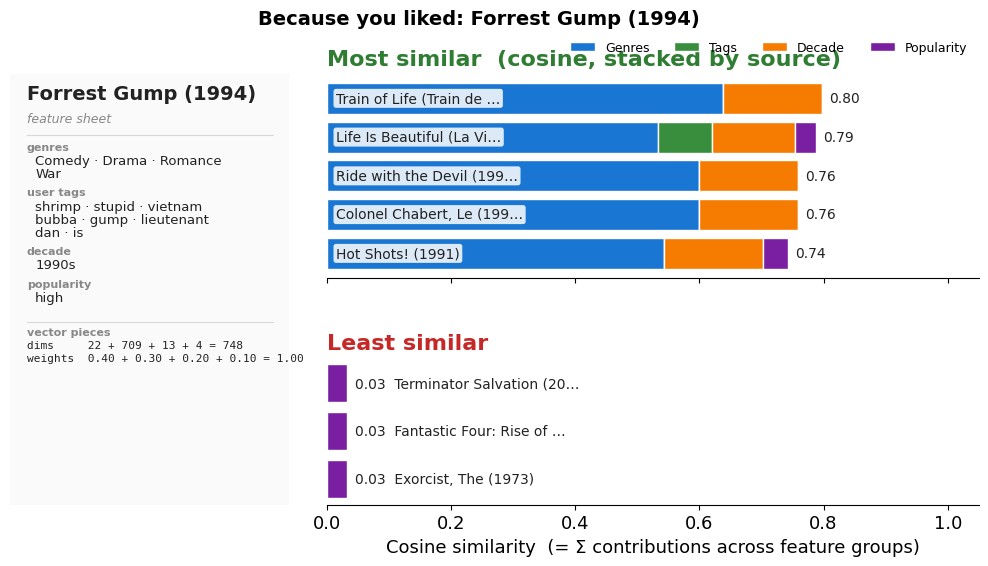

In [18]:
show_similar('Forrest Gump')

### Where TF-IDF still falls short

TF-IDF only sees **the exact words you wrote**. It misses everything else:

| Problem | Example |
|---|---|
| **Synonyms** | "automobile" and "car" treated as unrelated columns |
| **Polysemy** | "bank" (river) vs "bank" (money) collapsed into one weight |
| **Theme vs. words** | A *comedy* and a *horror* both about "space" get a high score |
| **Order & syntax** | "dog bites man" and "man bites dog" produce identical vectors |

The fix: learn a **dense embedding** where direction = meaning (Word2Vec, BERT, sentence transformers). That's the next slide, and the topic of Session 9.


## Word Embeddings: meaning becomes direction

TF-IDF still treats *king* and *queen* as unrelated columns. **Word embeddings** (Word2Vec, GloVe) learn a dense vector per word from huge text corpora, so that **directions carry meaning**.

The famous example:

$$\vec{king} - \vec{man} + \vec{woman} \;\approx\; \vec{queen}$$

The "male → female" step becomes a **consistent direction** anywhere in the space.

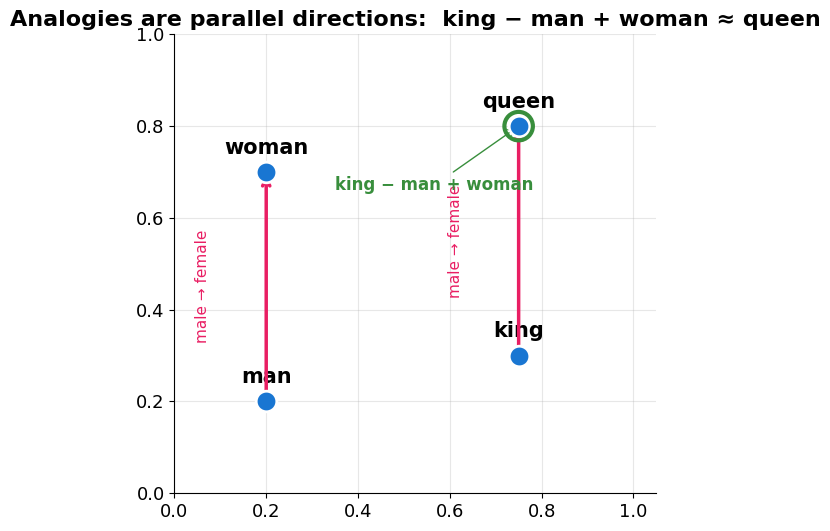

(Illustrative layout — the real vectors live in hundreds of dimensions.)


In [19]:
# Illustrative hand-placed embeddings (real Word2Vec/GloVe vectors do this in ~300-D).
words = {'man': (0.20, 0.20), 'woman': (0.20, 0.70),
         'king': (0.75, 0.30), 'queen': (0.75, 0.80)}

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for w, (x, y) in words.items():
    ax.scatter(x, y, s=220, color='#1976d2', zorder=5, edgecolors='white', linewidth=2)
    ax.text(x, y + 0.04, w, fontsize=15, fontweight='bold', ha='center')

# the two parallel "male -> female" directions
for start, end in [('man', 'woman'), ('king', 'queen')]:
    ax.annotate('', xy=words[end], xytext=words[start],
                arrowprops=dict(arrowstyle='->', color='#e91e63', lw=2.5))
ax.text(0.045, 0.45, 'male → female', color='#e91e63', fontsize=11, rotation=90, va='center')
ax.text(0.595, 0.55, 'male → female', color='#e91e63', fontsize=11, rotation=90, va='center')

# king - man + woman lands on queen
pred = np.array(words['king']) - np.array(words['man']) + np.array(words['woman'])
ax.scatter(*pred, s=420, facecolors='none', edgecolors='#388e3c', linewidth=3, zorder=6)
ax.annotate('king − man + woman', xy=pred, xytext=(pred[0] - 0.40, pred[1] - 0.14),
            color='#388e3c', fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#388e3c'))

ax.set_title('Analogies are parallel directions:  king − man + woman ≈ queen', fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.0)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print('(Illustrative layout — the real vectors live in hundreds of dimensions.)')

### Why embeddings beat TF-IDF: similar wording, different meaning

Three short plot blurbs:

- **Batman** — "a masked **man** fights crime in Gotham city at night"
- **Notting Hill** — "a quiet **man** falls deeply in love with a famous actress in London"
- **The Punisher** — "a brutal vigilante hunts down ruthless criminals across a dark metropolis"

To TF-IDF, the **shared surface word "man"** makes Batman look closer to a romance than to a crime drama. Embeddings know better — they read *meaning*, not letters.


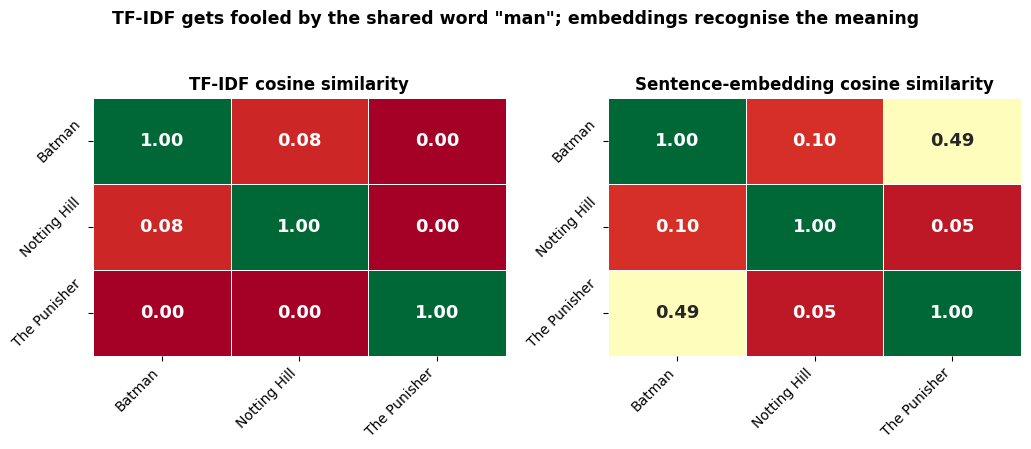

TF-IDF says Batman is closer to Notting Hill (0.08) than to The Punisher (0.00).
Embeddings say Batman is closer to The Punisher (0.49) than to Notting Hill (0.10).


In [20]:
# Compare TF-IDF (counts words) with sentence embeddings (reads meaning).
# Sentence embeddings are pre-trained vectors for whole sentences; we cover them in Session 9.
import importlib.util, subprocess, sys
if importlib.util.find_spec('sentence_transformers') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sentence-transformers'], check=False)
import os, logging, warnings, contextlib
# Silence verbose model-loading output -- transformers prints a state-dict
# 'LOAD REPORT' and HF Hub prints an auth nag; neither is useful for students.
# Some of this output is written at the C level (bypassing sys.stderr),
# so we redirect file descriptor 2 in addition to setting env vars + loggers.
os.environ.setdefault('TRANSFORMERS_VERBOSITY', 'error')
os.environ.setdefault('TRANSFORMERS_NO_ADVISORY_WARNINGS', '1')
os.environ.setdefault('HF_HUB_DISABLE_PROGRESS_BARS', '1')
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('sentence_transformers').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

@contextlib.contextmanager
def _silence_fd2():
    """Suppress writes to OS file descriptor 2 (raw stderr), which Python's
    contextlib.redirect_stderr cannot catch."""
    saved = os.dup(2)
    null = os.open(os.devnull, os.O_WRONLY)
    os.dup2(null, 2)
    try:
        yield
    finally:
        os.dup2(saved, 2); os.close(saved); os.close(null)

from sentence_transformers import SentenceTransformer

blurbs = {
    'Batman':       'a masked man fights crime in Gotham city at night',
    'Notting Hill': 'a quiet man falls deeply in love with a famous actress in London',
    'The Punisher': 'a brutal vigilante hunts down ruthless criminals across a dark metropolis',
}
titles = list(blurbs)

# (1) TF-IDF cosine similarity -- the baseline.
X_tfidf = TfidfVectorizer(stop_words='english').fit_transform(blurbs.values())
sim_tfidf = cosine_similarity(X_tfidf)

# (2) Sentence-embedding cosine similarity (all-MiniLM-L6-v2, 384-D).
with _silence_fd2():
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
emb = model.encode(list(blurbs.values()), normalize_embeddings=True)
sim_emb = emb @ emb.T

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, M, title in [(axes[0], sim_tfidf, 'TF-IDF cosine similarity'),
                     (axes[1], sim_emb,   'Sentence-embedding cosine similarity')]:
    sns.heatmap(M, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=titles, yticklabels=titles,
                linewidths=0.5, linecolor='white', ax=ax, cbar=False,
                annot_kws={'fontsize': 13, 'fontweight': 'bold'})
    ax.set_title(title, fontweight='bold', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    plt.setp(ax.get_yticklabels(), rotation=45, ha='right', fontsize=10)

plt.suptitle('TF-IDF gets fooled by the shared word "man"; embeddings recognise the meaning',
             fontsize=12.5, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'TF-IDF says Batman is closer to Notting Hill ({sim_tfidf[0,1]:.2f}) than to The Punisher ({sim_tfidf[0,2]:.2f}).')
print(f'Embeddings say Batman is closer to The Punisher ({sim_emb[0,2]:.2f}) than to Notting Hill ({sim_emb[0,1]:.2f}).')

## The bigger picture: Information Retrieval

> *Information Retrieval (IR) is finding material (usually documents) of an unstructured nature that satisfies an information need from within large collections.*
> — Manning, Raghavan & Schütze, *Introduction to Information Retrieval* (2008)

A recommender returning "items similar to your profile" is doing exactly this — it is a **search engine whose query is *you***.

That reframing lets us borrow IR's evaluation toolkit: **how good is a ranked list of results?**

## Evaluating a ranked list: Precision & Recall

Label each returned item **relevant** or **not**, then compare to the truth:

<div style="display:flex; gap:3em; align-items:center; justify-content:center; margin-top:0.6em;">

<div>

|                       | relevant              | not relevant          |
|-----------------------|-----------------------|-----------------------|
| **retrieved**         | TP — *True Positive*  | FP — *False Positive* |
| **not retrieved**     | FN — *False Negative* | TN — *True Negative*  |

</div>

<div style="text-align:center; font-size:0.95em;">

$$\text{Precision}=\frac{TP}{TP+FP}$$

*of what I returned, how much was good?*

$$\text{Recall}=\frac{TP}{TP+FN}$$

*of all good items, how many did I find?*

$$F_1 = \frac{2\,P\,R}{P+R}$$

*harmonic mean — handy when balancing both.*

</div>

</div>

Return **more** items → recall rises, precision usually falls. Report metrics **@k** (the top-k items).

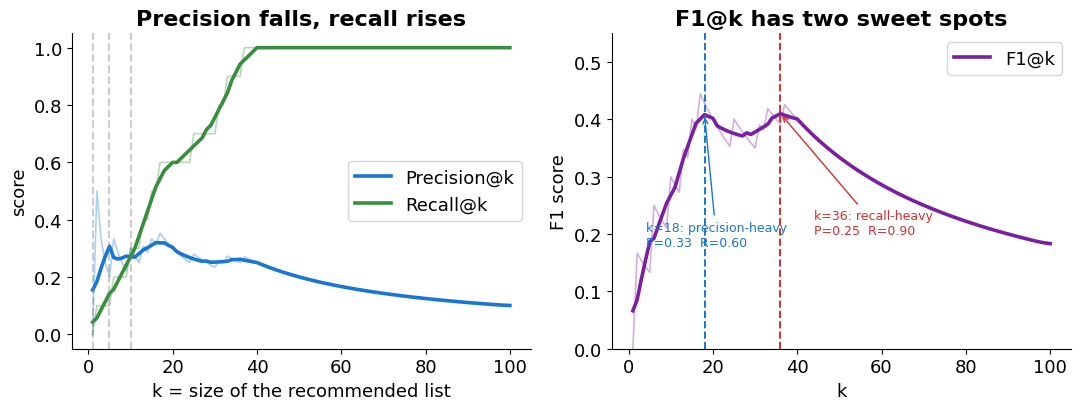

Two sweet spots: k=18 (precision-heavy) and k=36 (balanced trade-off).
At k=10:  P=0.30, R=0.30, F1=0.30.


In [21]:
# Worked example: 100 ranked items, 10 of them relevant; a decent recommender front-loads them.
rng = np.random.default_rng(1)
N, R = 100, 10
ranked = np.zeros(N, dtype=int)
ranked[np.sort(rng.choice(np.arange(0, 40), size=R, replace=False))] = 1   # relevants front-loaded

k = np.arange(1, N + 1)
tp = np.cumsum(ranked)
precision = tp / k
recall    = tp / R
f1 = np.divide(2 * precision * recall, precision + recall,
               out=np.zeros_like(precision), where=(precision + recall) > 0)


def smooth(y, w=7):
    pad = w // 2
    padded = np.pad(y, pad, mode='edge')
    return np.convolve(padded, np.ones(w) / w, mode='valid')


f1_smooth = smooth(f1)
# Find the two visible local maxima of F1@k with scipy.signal.find_peaks.
# Sort the detected peaks by k; the first is the high-precision-low-recall peak,
# the last is the balanced-trade-off peak (also where recall has saturated).
from scipy.signal import find_peaks
peaks, _ = find_peaks(f1_smooth, distance=5, prominence=0.01)
if len(peaks) >= 2:
    early_peak, late_peak = int(peaks[0]), int(peaks[-1])
else:
    # fallback: split on the global max
    g = int(np.argmax(f1_smooth))
    early_peak = int(np.argmax(f1_smooth[:max(g, 1)]))
    late_peak  = g
k_early, k_late = early_peak + 1, late_peak + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))

# (1) Precision & recall as k grows.
ax1.plot(k, precision, color='#1976d2', lw=1.2, alpha=0.35)
ax1.plot(k, recall,    color='#388e3c', lw=1.2, alpha=0.35)
ax1.plot(k, smooth(precision), color='#1976d2', lw=2.6, label='Precision@k')
ax1.plot(k, smooth(recall),    color='#388e3c', lw=2.6, label='Recall@k')
for kk in (1, 5, 10):
    ax1.axvline(kk, color='gray', ls='--', alpha=0.4)
ax1.set_xlabel('k = size of the recommended list')
ax1.set_ylabel('score')
ax1.set_title('Precision falls, recall rises', fontweight='bold')
ax1.legend(loc='center right')
ax1.spines[['top', 'right']].set_visible(False)

# (2) F1@k with both sweet spots annotated.
ax2.plot(k, f1, color='#7b1fa2', lw=1.2, alpha=0.35)
ax2.plot(k, f1_smooth, color='#7b1fa2', lw=2.6, label='F1@k')
ax2.axvline(k_early, color='#1976d2', ls='--', lw=1.4)
ax2.axvline(k_late,  color='#d32f2f', ls='--', lw=1.4)
ax2.set_ylim(0, 0.55)   # leave headroom for the title and the annotations.
ax2.annotate(f'k={k_early}: precision-heavy\nP={precision[k_early-1]:.2f}  R={recall[k_early-1]:.2f}',
             xy=(k_early, f1_smooth[early_peak]),
             xytext=(k_early - 14, 0.18),
             fontsize=9, color='#1976d2', ha='left',
             arrowprops=dict(arrowstyle='->', color='#1976d2', lw=1))
ax2.annotate(f'k={k_late}: recall-heavy\nP={precision[k_late-1]:.2f}  R={recall[k_late-1]:.2f}',
             xy=(k_late, f1_smooth[late_peak]),
             xytext=(k_late + 8, 0.20),
             fontsize=9, color='#d32f2f', ha='left',
             arrowprops=dict(arrowstyle='->', color='#d32f2f', lw=1))
ax2.set_xlabel('k')
ax2.set_ylabel('F1 score')
ax2.set_title('F1@k has two sweet spots', fontweight='bold')
ax2.legend(loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
print(f'Two sweet spots: k={k_early} (precision-heavy) and k={k_late} (balanced trade-off).')
print(f'At k=10:  P={precision[9]:.2f}, R={recall[9]:.2f}, F1={f1[9]:.2f}.')

## Limitations of Content-Based Methods

Even after stacking richer signals — **genres + tags + decade + popularity** in our demo — three structural problems remain:

- **Feature-engineering bottleneck** — every column is a signal someone had to design, label, and maintain. Tags need curators; cast lists need a source like IMDB; missing fields (no tags, no popularity bucket) silently weaken the vector. And TF-IDF still can't tell *car* from *automobile*, no matter how many columns we add.
- **No serendipity** — you only ever get *more of the same*. Aggarwal calls this **over-specialization**: even when a great pick lies in an unfamiliar category (your first Ethiopian restaurant), the recommender keeps proposing variations of what you already know.
- **Curse of dimensionality** — richer features mean huge, sparse vectors where distance metrics blur (cf. the earlier slide on $d \to \infty$).

**Next lecture: matrix factorization.** Drop the hand-designed columns and let the *data* discover which dimensions matter — including the implicit ones (mood, pacing, "feels like a 90s indie") that no tag captures.

### Cold Start: Partially Solved

Content-based methods **can** handle new items — as long as they have features (genres, description, image), we can build a vector and compare.

But **new users** remain a problem: without any ratings, we have no profile vector to match against.

*Remember this — we'll revisit cold start in every remaining lecture.*

## Key Takeaways

1. **Everything becomes a vector** — items, users, text, images — in one shared feature space.
2. **Similarity is geometry:** cosine = angle (ignores length), Euclidean = distance, dot product = both.
3. **Content-based recommending** = match a user-profile vector to item vectors ("because you liked…").
4. **TF-IDF & embeddings** turn unstructured data into vectors automatically — the same similarity tools apply.
5. **Evaluate** a ranked list with Precision@k / Recall@k — it's Information Retrieval.
6. **Cold start:** fine for new *items*, fails for new *users*; plus no serendipity and hand-crafted features don't scale.

**→ Next lecture: Matrix Factorization — let the *data* discover the features.